# How floruit periods were assigned

Each individual receives a `floruit_period` (text). The default span covers ages 30 to 55 (a 25-year window). The end of the period is capped at the current year (2026) for year/decade-precise rules.

The `method` column tags each row with one of five values:

| `method` | What it means | Floruit |
|---|---|---|
| `floruit` | Wikidata floruit (P1317) was used | `[floruit_year, floruit_year + 25]`, capped by death year |
| `birth` | Birth year was the driver, year/decade precise | `[birth + 30, min(birth + 55, death, 2026)]` |
| `death` | Only year/decade-precise death was usable | `[death - 25, death]` |
| `birth_century` | Birth was used but is only century-precise | the formal century label, e.g. `12th c. AD` |
| `death_century` | Only a century-precise death was usable | the formal century label |

Edge cases: contradictory dates (birth > death) drop the death; mixed precisions defer to the more precise one; decade-precision dates are taken at the first year of the decade. Century labels follow the formal convention: 700 → 7th c. AD (last year of the 7th century), 750 → 8th c. AD, 1899 → 19th c. AD.

In [ ]:
# === notebook config (auto-managed; edit values, not the tag) ===
import random
import numpy as np

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Database
DB_PATH = "../data/humans_clean.sqlite3"

# Figure style — minimal, Nature/Science publication standard
FIGSIZE = (8, 5)
DPI = 120
FONT_TITLE = 16
FONT_LABEL = 13
FONT_TICK = 11
FONT_LEGEND = 10

# Light, restrained palette (avoid AI-slop saturation)
COLOR_PRIMARY = "#2171b5"
COLOR_SECONDARY = "#b5542a"
COLOR_NEUTRAL = "#7f7f7f"
COLOR_LIGHT = "#d9d9d9"
COLOR_ACCENT = "#6a9e3a"
PALETTE = [COLOR_PRIMARY, COLOR_SECONDARY, COLOR_ACCENT, COLOR_NEUTRAL, COLOR_LIGHT]

import matplotlib as _mpl
_mpl.rcParams.update({
    "figure.figsize": FIGSIZE,
    "figure.dpi": DPI,
    "axes.titlesize": FONT_TITLE,
    "axes.labelsize": FONT_LABEL,
    "xtick.labelsize": FONT_TICK,
    "ytick.labelsize": FONT_TICK,
    "legend.fontsize": FONT_LEGEND,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})


In [ ]:
import sqlite3
import re
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

DB = DB_PATH

LABEL_FLORUIT      = 'Floruit from Wikidata floruit (P1317)'
LABEL_BIRTH        = 'Floruit from birth date'
LABEL_BIRTH_CENT   = 'Floruit from birth date (century precision)'
LABEL_BIRTH_CAPPED = 'Floruit from birth date, capped by death'
LABEL_DEATH        = 'Floruit from death date'
LABEL_DEATH_CENT   = 'Floruit from death date (century precision)'

ORDER = [
    LABEL_FLORUIT,
    LABEL_BIRTH,
    LABEL_BIRTH_CENT,
    LABEL_BIRTH_CAPPED,
    LABEL_DEATH,
    LABEL_DEATH_CENT,
]

COLORS = {
    LABEL_FLORUIT:      '#e6194b',
    LABEL_BIRTH:        '#3cb44b',
    LABEL_BIRTH_CENT:   '#ffe119',
    LABEL_BIRTH_CAPPED: '#4363d8',
    LABEL_DEATH:        '#f58231',
    LABEL_DEATH_CENT:   '#911eb4',
}

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 12,
    'font.family': 'DejaVu Sans',
})


# Parse "1880-1905" or "12th c. AD" or "2nd c. BC" into a representative
# integer year for binning (start of the period).
_YEAR_RE = re.compile(r'^(-?\d+)')
_CENT_RE = re.compile(r'^(\d+)\D*\s*c\.\s*(AD|BC)$', re.IGNORECASE)

def period_start_year(period: str):
    if period is None:
        return None
    s = period.split('-')[0].split('–')[0].strip()
    m = _CENT_RE.match(s)
    if m:
        n = int(m.group(1))
        era = m.group(2).upper()
        # nth c. AD = (n-1)*100+1 .. n*100, label by start of century
        return (n - 1) * 100 + 1 if era == 'AD' else -(n * 100)
    m = _YEAR_RE.match(s)
    if m:
        return int(m.group(1))
    return None


## Load and re-classify

We pull the four columns we need and remap the database `method` (5 values: `floruit`, `birth`, `death`, `birth_century`, `death_century`) into six display labels — splitting `birth` into "Birth" and "Birth, capped by death" using `birth_year` and `death_year` (the cap fires when `death_year < birth_year + 55`).

In [2]:
conn = sqlite3.connect(DB)
df_pd = pd.read_sql(
    """
    SELECT method, birth_year, death_year, floruit_period
    FROM individuals_floruit_period
    WHERE method IS NOT NULL
    """,
    conn,
)
conn.close()

# Add a numeric anchor year for binning (start of the period or century).
df_pd['floruit_start'] = df_pd['floruit_period'].map(period_start_year)
df = pl.from_pandas(df_pd)

df = df.with_columns(
    pl.when(pl.col('method') == 'floruit')
      .then(pl.lit(LABEL_FLORUIT))
    .when(pl.col('method') == 'birth_century')
      .then(pl.lit(LABEL_BIRTH_CENT))
    .when(pl.col('method') == 'death_century')
      .then(pl.lit(LABEL_DEATH_CENT))
    .when(pl.col('method') == 'death')
      .then(pl.lit(LABEL_DEATH))
    # `birth` capped by death (year/decade-precise birth + death, death < birth+55)
    .when(
        (pl.col('method') == 'birth')
        & pl.col('birth_year').is_not_null()
        & pl.col('death_year').is_not_null()
        & (pl.col('death_year') < pl.col('birth_year') + 55)
    )
      .then(pl.lit(LABEL_BIRTH_CAPPED))
    .when(pl.col('method') == 'birth')
      .then(pl.lit(LABEL_BIRTH))
    .otherwise(pl.lit('Other'))
    .alias('label')
).filter(pl.col('label') != 'Other')

print(f'Total individuals: {df.height:,}')
print(df.group_by('label').agg(pl.len().alias('n')).sort('n', descending=True).to_pandas())

Total individuals: 7,508,361
                                         label        n
0                      Floruit from birth date  6390927
1     Floruit from birth date, capped by death   655855
2                      Floruit from death date   286538
3  Floruit from birth date (century precision)   105449
4        Floruit from Wikidata floruit (P1317)    66818
5  Floruit from death date (century precision)     2774


## 1. Counts per assignment rule

In [3]:
counts = (
    df.group_by('label')
      .agg(pl.len().alias('n'))
      .with_columns((pl.col('n') / df.height * 100).round(2).alias('share_%'))
)
rank = {l: i for i, l in enumerate(ORDER)}
counts = counts.sort(by=pl.col('label').map_elements(
    lambda x: rank.get(x, 99), return_dtype=pl.Int32))
counts.to_pandas()

,label,n,share_%
0,Floruit from Wikidata floruit (P1317),66818,0.89
1,Floruit from birth date,6390927,85.12
2,Floruit from birth date (century precision),105449,1.40
3,"Floruit from birth date, capped by death",655855,8.73
4,Floruit from death date,286538,3.82
5,Floruit from death date (century precision),2774,0.04


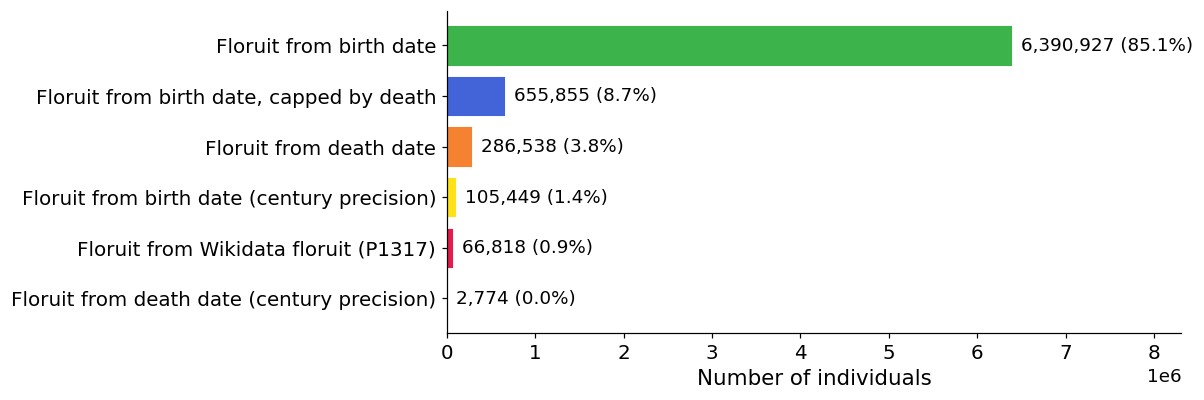

In [4]:
plot_df = counts.sort('n').to_pandas()

fig, ax = plt.subplots(figsize=(11, 3.8))
ax.barh(plot_df['label'], plot_df['n'],
        color=[COLORS[l] for l in plot_df['label']],
        edgecolor='white', linewidth=0.6)
for y, (n, p) in enumerate(zip(plot_df['n'], plot_df['share_%'])):
    ax.annotate(f'{n:,} ({p:.1f}%)', xy=(n, y),
                xytext=(6, 0), textcoords='offset points',
                va='center', fontsize=12)
ax.set_xlabel('Number of individuals', fontsize=14)
ax.tick_params(axis='x', labelsize=13)
ax.tick_params(axis='y', labelsize=13)
ax.margins(x=0.30)
plt.tight_layout()
plt.show()

## 2. Coverage over time

Each individual is binned by their floruit start year, rounded down to the start of the century. The stack shows the share of methods used in each century.

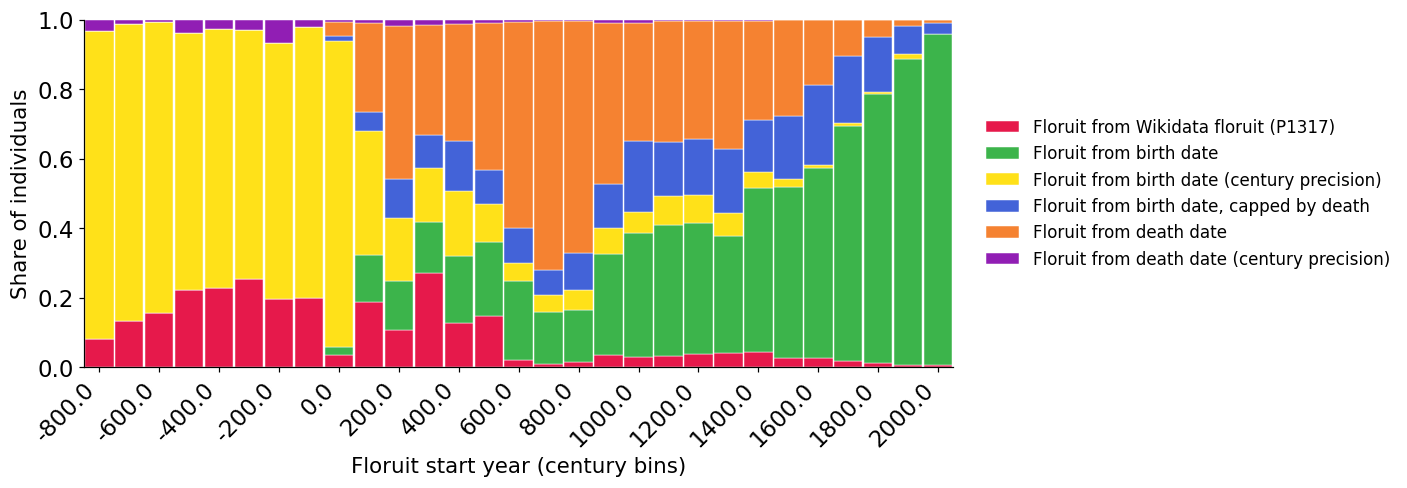

Counts in last 12 bins:


,Floruit from Wikidata floruit (P1317),Floruit from birth date,Floruit from birth date (century precision),"Floruit from birth date, capped by death",Floruit from death date,Floruit from death date (century precision)
bin,,,,,,
900.0,263,2146,540,941,3414,62
1000.0,291,3548,602,2030,3384,91
1100.0,468,5701,1238,2374,5227,63
1200.0,805,8073,1667,3475,7197,114
1300.0,1048,8914,1742,4936,9697,114
1400.0,1981,20593,2086,6499,12523,130
1500.0,2512,46801,2193,17226,26033,239
1600.0,4652,93130,1685,39164,31769,187
1700.0,4778,193965,1908,55102,30133,118


In [5]:
BIN = 100
YEAR_MIN, YEAR_MAX = -800, 2000

binned = (
    df.filter(pl.col('floruit_start').is_between(YEAR_MIN, YEAR_MAX))
      .with_columns(((pl.col('floruit_start') // BIN) * BIN).alias('bin'))
)

wide = (
    binned.group_by(['bin', 'label']).agg(pl.len().alias('n'))
          .pivot(values='n', index='bin', on='label').fill_null(0)
          .sort('bin')
)
for lab in ORDER:
    if lab not in wide.columns:
        wide = wide.with_columns(pl.lit(0).alias(lab))
wide = wide.select(['bin'] + ORDER)

wide_p = wide.to_pandas().set_index('bin')
totals = wide_p[ORDER].sum(axis=1).replace(0, np.nan)
shares = wide_p[ORDER].div(totals, axis=0).fillna(0)

bins = wide_p.index.tolist()
x = np.arange(len(bins))

fig, ax = plt.subplots(figsize=(13, 4.6))
bottom = np.zeros(len(bins))
for lab in ORDER:
    vals = shares[lab].values
    ax.bar(x, vals, bottom=bottom, width=0.95,
           color=COLORS[lab], edgecolor='white', linewidth=0.3, label=lab)
    bottom = bottom + vals

label_years = {b for b in bins if b % 200 == 0}
label_years.update({bins[0], bins[-1]})
xt  = [i for i, b in enumerate(bins) if b in label_years]
xtl = [str(bins[i]) for i in xt]
ax.set_xticks(xt)
ax.set_xticklabels(xtl, fontsize=15, rotation=45, ha='right')
ax.tick_params(axis='y', labelsize=15)
ax.set_ylim(0, 1)
ax.set_xlim(-0.5, len(bins) - 0.5)
ax.set_ylabel('Share of individuals', fontsize=14)
ax.set_xlabel('Floruit start year (century bins)', fontsize=14)
ax.legend(frameon=False, fontsize=11, loc='center left',
          bbox_to_anchor=(1.02, 0.5), ncol=1)
plt.tight_layout()
plt.show()

print('Counts in last 12 bins:')
wide_p.tail(12)

## 3. Floruit count per century

Each individual is binned by their `floruit_start` rounded down to the start of the century containing it. The bars are stacked by which rule produced the floruit, so the two century-precision categories pile up at exact century boundaries (point estimates), while the year/decade-precise rules spread within the century.

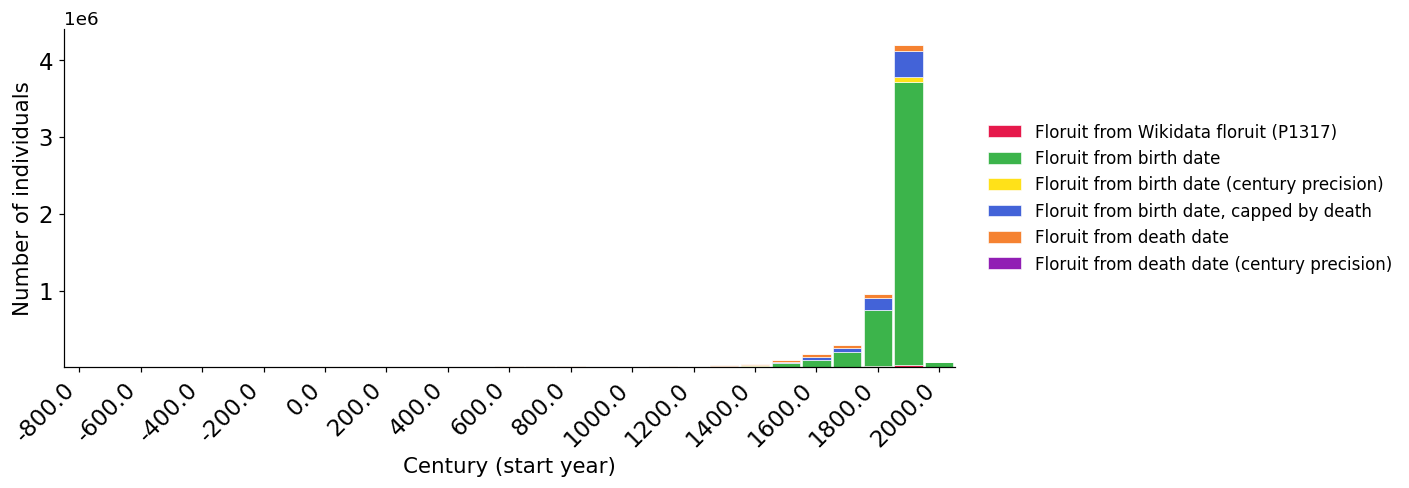

Counts in last 12 centuries:


,Floruit from Wikidata floruit (P1317),Floruit from birth date,Floruit from birth date (century precision),"Floruit from birth date, capped by death",Floruit from death date,Floruit from death date (century precision)
century,,,,,,
900.0,263,2146,540,941,3414,62
1000.0,291,3548,602,2030,3384,91
1100.0,468,5701,1238,2374,5227,63
1200.0,805,8073,1667,3475,7197,114
1300.0,1048,8914,1742,4936,9697,114
1400.0,1981,20593,2086,6499,12523,130
1500.0,2512,46801,2193,17226,26033,239
1600.0,4652,93130,1685,39164,31769,187
1700.0,4778,193965,1908,55102,30133,118


In [6]:
CENTURY_MIN, CENTURY_MAX = -800, 2000

cent = (
    df.filter(pl.col('floruit_start').is_between(CENTURY_MIN, CENTURY_MAX))
      .with_columns(
          (pl.col('floruit_start').floordiv(100).mul(100)).alias('century')
      )
)

cwide = (
    cent.group_by(['century', 'label']).agg(pl.len().alias('n'))
        .pivot(values='n', index='century', on='label').fill_null(0)
        .sort('century')
)
for lab in ORDER:
    if lab not in cwide.columns:
        cwide = cwide.with_columns(pl.lit(0).alias(lab))
cwide = cwide.select(['century'] + ORDER)
cwide_p = cwide.to_pandas().set_index('century')

centuries = cwide_p.index.tolist()
xc = np.arange(len(centuries))

fig, ax = plt.subplots(figsize=(13, 4.6))
bottom = np.zeros(len(centuries))
for lab in ORDER:
    vals = cwide_p[lab].values.astype(float)
    ax.bar(xc, vals, bottom=bottom, width=0.92,
           color=COLORS[lab], edgecolor='white', linewidth=0.4, label=lab)
    bottom = bottom + vals

label_centuries = {c for c in centuries if c % 200 == 0}
label_centuries.update({centuries[0], centuries[-1]})
xt  = [i for i, c in enumerate(centuries) if c in label_centuries]
xtl = [str(centuries[i]) for i in xt]
ax.set_xticks(xt)
ax.set_xticklabels(xtl, fontsize=15, rotation=45, ha='right')
ax.tick_params(axis='y', labelsize=15)
ax.set_xlim(-0.5, len(centuries) - 0.5)
ax.set_ylabel('Number of individuals', fontsize=14)
ax.set_xlabel('Century (start year)', fontsize=14)
ax.legend(frameon=False, fontsize=11, loc='center left',
          bbox_to_anchor=(1.02, 0.5), ncol=1)
plt.tight_layout()
plt.show()

print('Counts in last 12 centuries:')
cwide_p.tail(12)

## 3. Worked examples

Five rows per label.

In [7]:
conn = sqlite3.connect(DB)
raw_pd = pd.read_sql(
    """
    SELECT method, wikidata_id, name_en,
           birth_year, birthdate_precision,
           death_year, deathdate_precision,
           floruit_year, floruit_precision,
           floruit_period
    FROM individuals_floruit_period
    WHERE method IS NOT NULL
      AND name_en IS NOT NULL
    """,
    conn,
)
conn.close()
raw = pl.from_pandas(raw_pd)

raw = raw.with_columns(
    pl.when(pl.col('method') == 'floruit')
      .then(pl.lit(LABEL_FLORUIT))
    .when(pl.col('method') == 'birth_century')
      .then(pl.lit(LABEL_BIRTH_CENT))
    .when(pl.col('method') == 'death_century')
      .then(pl.lit(LABEL_DEATH_CENT))
    .when(pl.col('method') == 'death')
      .then(pl.lit(LABEL_DEATH))
    .when(
        (pl.col('method') == 'birth')
        & pl.col('birth_year').is_not_null()
        & pl.col('death_year').is_not_null()
        & (pl.col('death_year') < pl.col('birth_year') + 55)
    )
      .then(pl.lit(LABEL_BIRTH_CAPPED))
    .when(pl.col('method') == 'birth')
      .then(pl.lit(LABEL_BIRTH))
    .otherwise(pl.lit('Other'))
    .alias('label')
).filter(pl.col('label') != 'Other')

samples = []
for lab in ORDER:
    sub = raw.filter(pl.col('label') == lab)
    if sub.height > 0:
        samples.append(sub.sample(n=min(5, sub.height), seed=0))
examples = pl.concat(samples)
examples.select(['label', 'wikidata_id', 'name_en',
                 'birth_year', 'birthdate_precision',
                 'death_year', 'deathdate_precision',
                 'floruit_year',
                 'floruit_period']).to_pandas()

,label,wikidata_id,name_en,birth_year,birthdate_precision,death_year,deathdate_precision,floruit_year,floruit_period
0,Floruit from Wikidata floruit (P1317),Q120034024,Pietro Castelli,1450.0,7.0,1550.0,7.0,1517.0,1517-1542
1,Floruit from Wikidata floruit (P1317),Q125937281,Anne-Marie Verpoucke,1948.0,9.0,NaN,NaN,1982.0,1982-2007
2,Floruit from Wikidata floruit (P1317),Q124355165,Frederik de Wal,1963.0,11.0,NaN,NaN,2009.0,2009-2026
3,Floruit from Wikidata floruit (P1317),Q104307402,Jerry Aerts,1955.0,9.0,NaN,NaN,1992.0,1992-2017
4,Floruit from Wikidata floruit (P1317),Q133870665,Ch. Th. Reichardus,NaN,NaN,NaN,NaN,1833.0,1833-1858
5,Floruit from birth date,Q137355149,Hippolyte Lejeune,1804.0,11.0,NaN,NaN,NaN,1834-1859
6,Floruit from birth date,Q1688715,Yevhen Hurkovskyi,1980.0,11.0,NaN,NaN,NaN,2010-2026
7,Floruit from birth date,Q16121367,J. Curtis Joyner,1948.0,9.0,NaN,NaN,NaN,1978-2003
8,Floruit from birth date,Q102388640,James Rogers,1733.0,11.0,1803.0,11.0,NaN,1763-1788
9,Floruit from birth date,Q26203979,Alexander Dawson,1771.0,9.0,1831.0,11.0,NaN,1801-1826
